# Basic Two-Channel Analysis

Time-of-flight analysis, charge distributions, and basic characterization of neutron-gamma coincidence data.

In [88]:
from __future__ import annotations

import logging
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

try:
    import lecroyparser
except ImportError as exc:
    raise ImportError("lecroyparser required. Install: pip install lecroyparser") from exc

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("two_channel")

# Import analysis functions from lib
from lib import (
    TwoChannelConfig, Waveform, TwoChannelEvent,
    find_channel_pairs, load_waveform,
    analyze_channel, analyze_pair, compute_baseline,
    plot_stacked_waveforms, plot_pair_comparison,
    plot_waveform_with_features, extract_waveform_shape_features,
    create_analysis_report
)

max_analyzed_events = -1  # Limit the number of events to analyze for performance reasons

In [89]:
# ConfigurationWORKDIR = Path("/Users/virgolaema/Software/3det/Osc_Data")WAVEFORM_DIR = WORKDIR / "AmBe_therma_coincidence_1750V_3x3_sample"RESULTS_DIR = Path("../docs/output")config = TwoChannelConfig(    waveform_dir=WAVEFORM_DIR,    results_dir=RESULTS_DIR,    ch1_pattern="C1_",    ch2_pattern="C2_",    file_extension=".trc",    baseline_window_ns=100.0,  # use first 100ns for baseline    charge_window_ns=(20.0, 40.0),  # 20ns left, 40ns right of peak    t0_threshold_fraction=0.5,  # 50% of peak amplitude for T0    t0_search_window_ns=100.0,    pulse_polarity="negative",    saturation_flatness_window_ns=10.0,    saturation_tolerance_v=0.0015,    saturation_fraction=0.3,    saturation_min_consecutive=5,    stack_plot_limit=50,    stack_alpha=0.3,    show_plots=True,    max_pairs=max_analyzed_events,  # Process only first 100 pairs for testing)logger.info("Configuration loaded")logger.info("Waveform directory: %s", config.waveform_dir)logger.info("Results directory: %s", config.results_dir)

2026-03-25 11:47:12,880 [INFO] Configuration loaded
2026-03-25 11:47:12,881 [INFO] Waveform directory: /Users/virgolaema/Software/3det/Osc_Data/AmBe_therma_coincidence_1750V_3x3_sample
2026-03-25 11:47:12,882 [INFO] Results directory: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma


In [90]:
# Find all channel pairs
pairs = find_channel_pairs(config)

if config.max_pairs:
    pairs = pairs[:config.max_pairs]
    logger.info("Limited to %d pairs for processing", len(pairs))
    

logger.info("Will process %d pairs", len(pairs))

2026-03-25 11:47:13,103 [INFO] Found 22198 total files
2026-03-25 11:47:13,135 [INFO] Found 11099 complete pairs
2026-03-25 11:47:13,136 [INFO] Limited to 11098 pairs for processing
2026-03-25 11:47:13,136 [INFO] Will process 11098 pairs


In [91]:
# Load all waveforms for stacking plots
ch1_waveforms = []
ch2_waveforms = []

logger.info("Loading waveforms...")
for i, (ch1_path, ch2_path) in enumerate(pairs):
    if i % 50 == 0:
        logger.info("Loading pair %d/%d", i, len(pairs))
    
    ch1_wf = load_waveform(ch1_path)
    ch2_wf = load_waveform(ch2_path)
    
    if ch1_wf is not None:
        ch1_waveforms.append(ch1_wf)
    if ch2_wf is not None:
        ch2_waveforms.append(ch2_wf)

logger.info("Loaded %d CH1 waveforms and %d CH2 waveforms", len(ch1_waveforms), len(ch2_waveforms))

2026-03-25 11:47:13,169 [INFO] Loading waveforms...
2026-03-25 11:47:13,169 [INFO] Loading pair 0/11098
2026-03-25 11:47:14,153 [INFO] Loading pair 50/11098
2026-03-25 11:47:15,155 [INFO] Loading pair 100/11098
2026-03-25 11:47:16,296 [INFO] Loading pair 150/11098
2026-03-25 11:47:17,302 [INFO] Loading pair 200/11098
2026-03-25 11:47:18,288 [INFO] Loading pair 250/11098
2026-03-25 11:47:19,418 [INFO] Loading pair 300/11098
2026-03-25 11:47:20,595 [INFO] Loading pair 350/11098
2026-03-25 11:47:21,637 [INFO] Loading pair 400/11098
2026-03-25 11:47:22,652 [INFO] Loading pair 450/11098
2026-03-25 11:47:23,677 [INFO] Loading pair 500/11098
2026-03-25 11:47:24,721 [INFO] Loading pair 550/11098
2026-03-25 11:47:25,766 [INFO] Loading pair 600/11098
2026-03-25 11:47:26,763 [INFO] Loading pair 650/11098
2026-03-25 11:47:27,765 [INFO] Loading pair 700/11098
2026-03-25 11:47:28,820 [INFO] Loading pair 750/11098
2026-03-25 11:47:29,901 [INFO] Loading pair 800/11098
2026-03-25 11:47:31,129 [INFO] Lo

2026-03-25 11:51:16,111 [INFO] Plotting stacked CH1 (Gamma) waveforms...


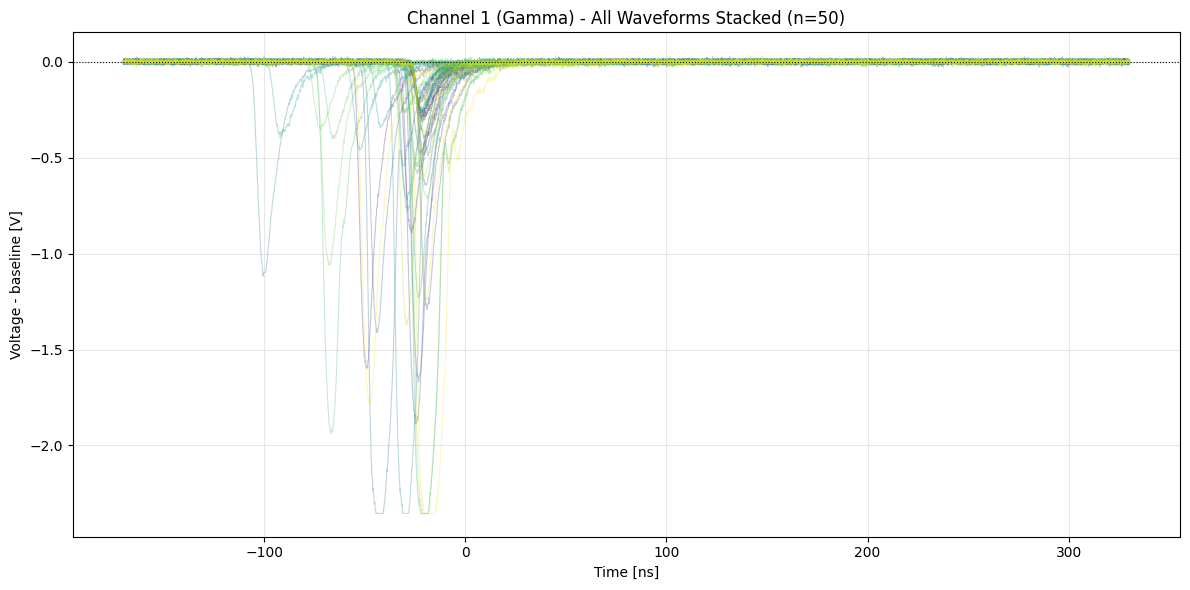

In [92]:
# Plot stacked waveforms for Channel 1 (Gamma)
logger.info("Plotting stacked CH1 (Gamma) waveforms...")
plot_stacked_waveforms(
    ch1_waveforms,
    config,
    title="Channel 1 (Gamma) - All Waveforms Stacked",
    save_path=config.results_dir / "ch1_gamma_stacked.png"
)

2026-03-25 11:51:16,355 [INFO] Plotting stacked CH2 (Neutron) waveforms...


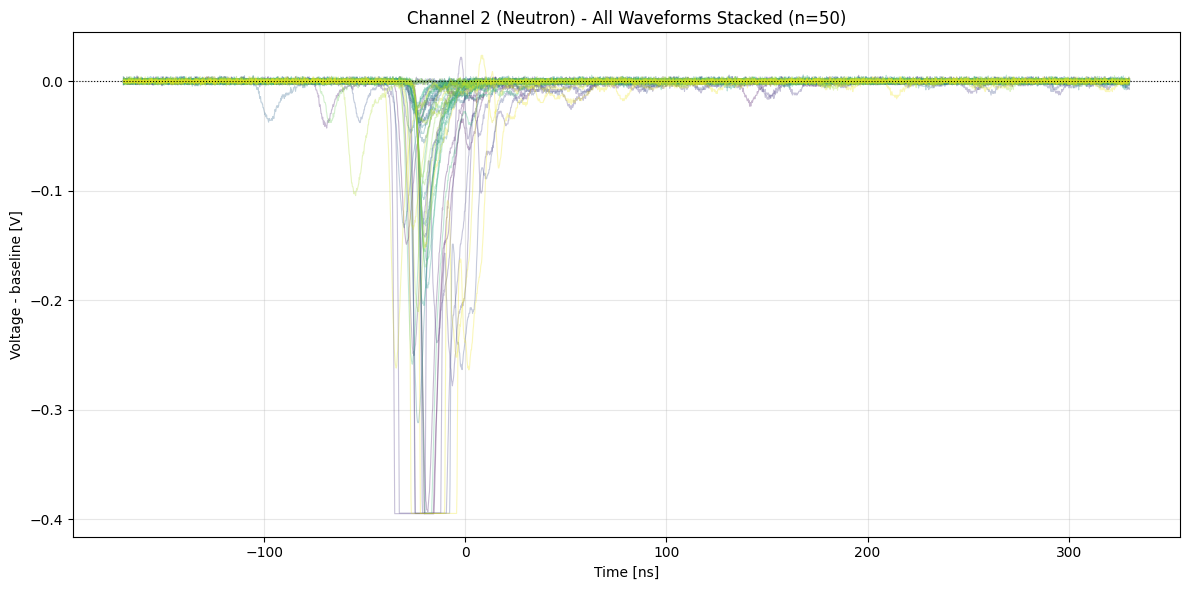

In [93]:
# Plot stacked waveforms for Channel 2 (Neutron)
logger.info("Plotting stacked CH2 (Neutron) waveforms...")
plot_stacked_waveforms(
    ch2_waveforms,
    config,
    title="Channel 2 (Neutron) - All Waveforms Stacked",
    save_path=config.results_dir / "ch2_neutron_stacked.png"
)

## Identify Neutron vs Gamma Channel

**After viewing the stacked plots above:**
- Compare pulse shapes, amplitudes, and timing
- Neutron signals typically show longer decay or different shape
- Update `neutron_channel` in the analysis cell below ("ch1" or "ch2")

For now, we assume **CH2 is the neutron channel** (saturation check enabled for CH2)

In [94]:
# Analyze all pairs
NEUTRON_CHANNEL = "ch2"  # CH2 = Neutron detector, CH1 = Gamma detector

events: List[TwoChannelEvent] = []
failed_pairs: List[Tuple[Path, Path, Exception]] = []

logger.info("Analyzing %d pairs...", len(pairs))
logger.info("Neutron channel: %s (saturation check enabled)", NEUTRON_CHANNEL)

for i, (ch1_path, ch2_path) in enumerate(pairs):
    if i % 50 == 0:
        logger.info("Analyzing pair %d/%d", i, len(pairs))
    
    try:
        ch1_wf = load_waveform(ch1_path)
        ch2_wf = load_waveform(ch2_path)
        
        if ch1_wf is None or ch2_wf is None:
            continue
        
        event = analyze_pair(ch1_wf, ch2_wf, config, neutron_channel=NEUTRON_CHANNEL)
        events.append(event)
        
    except Exception as exc:
        logger.error("Failed to analyze pair (%s, %s): %s", ch1_path.name, ch2_path.name, exc)
        failed_pairs.append((ch1_path, ch2_path, exc))

logger.info("Successfully analyzed %d pairs", len(events))
logger.info("Failed to analyze %d pairs", len(failed_pairs))

2026-03-25 11:51:16,587 [INFO] Analyzing 11098 pairs...
2026-03-25 11:51:16,588 [INFO] Neutron channel: ch2 (saturation check enabled)
2026-03-25 11:51:16,588 [INFO] Analyzing pair 0/11098
2026-03-25 11:51:17,643 [INFO] Analyzing pair 50/11098
2026-03-25 11:51:18,690 [INFO] Analyzing pair 100/11098
2026-03-25 11:51:19,749 [INFO] Analyzing pair 150/11098
2026-03-25 11:51:20,806 [INFO] Analyzing pair 200/11098
2026-03-25 11:51:22,002 [INFO] Analyzing pair 250/11098
2026-03-25 11:51:23,098 [INFO] Analyzing pair 300/11098
2026-03-25 11:51:24,272 [INFO] Analyzing pair 350/11098
2026-03-25 11:51:25,488 [INFO] Analyzing pair 400/11098
2026-03-25 11:51:26,596 [INFO] Analyzing pair 450/11098
2026-03-25 11:51:27,739 [INFO] Analyzing pair 500/11098
2026-03-25 11:51:29,035 [INFO] Analyzing pair 550/11098
2026-03-25 11:51:30,199 [INFO] Analyzing pair 600/11098
2026-03-25 11:51:31,522 [INFO] Analyzing pair 650/11098
2026-03-25 11:51:32,781 [INFO] Analyzing pair 700/11098
2026-03-25 11:51:34,023 [INF

In [95]:
# Filter saturated events (neutron channel only)
if NEUTRON_CHANNEL == "ch2":
    events_no_sat = [e for e in events if not e.ch2_saturated]
    n_saturated = len(events) - len(events_no_sat)
elif NEUTRON_CHANNEL == "ch1":
    events_no_sat = [e for e in events if not e.ch1_saturated]
    n_saturated = len(events) - len(events_no_sat)
else:
    events_no_sat = events
    n_saturated = 0

logger.info("Total events: %d", len(events))
logger.info("Saturated (neutron channel): %d (%.1f%%)", n_saturated, 100 * n_saturated / len(events) if events else 0)
logger.info("Events after saturation filter: %d", len(events_no_sat))

2026-03-25 11:55:18,198 [INFO] Total events: 11098
2026-03-25 11:55:18,198 [INFO] Saturated (neutron channel): 1967 (17.7%)
2026-03-25 11:55:18,199 [INFO] Events after saturation filter: 9131


In [96]:
# Save results to CSV
df_all = pd.DataFrame([e.to_dict() for e in events])
df_no_sat = pd.DataFrame([e.to_dict() for e in events_no_sat])

csv_all = config.results_dir / "two_channel_all_events.csv"
csv_no_sat = config.results_dir / "two_channel_no_saturation.csv"

df_all.to_csv(csv_all, index=False)
df_no_sat.to_csv(csv_no_sat, index=False)

logger.info("Saved all events to: %s", csv_all)
logger.info("Saved non-saturated events to: %s", csv_no_sat)

2026-03-25 11:55:18,395 [INFO] Saved all events to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/two_channel_all_events.csv
2026-03-25 11:55:18,395 [INFO] Saved non-saturated events to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/two_channel_no_saturation.csv


2026-03-25 11:55:18,399 [INFO] Plotting 5 example pairs...


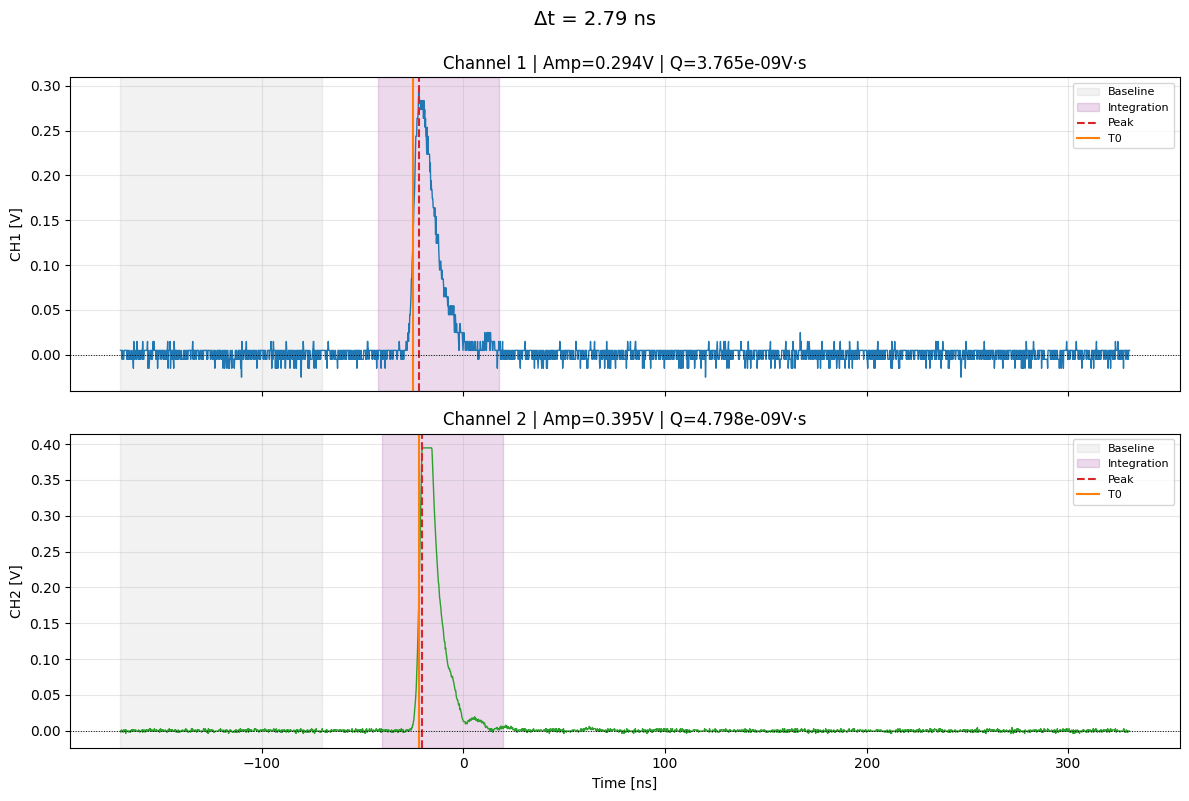

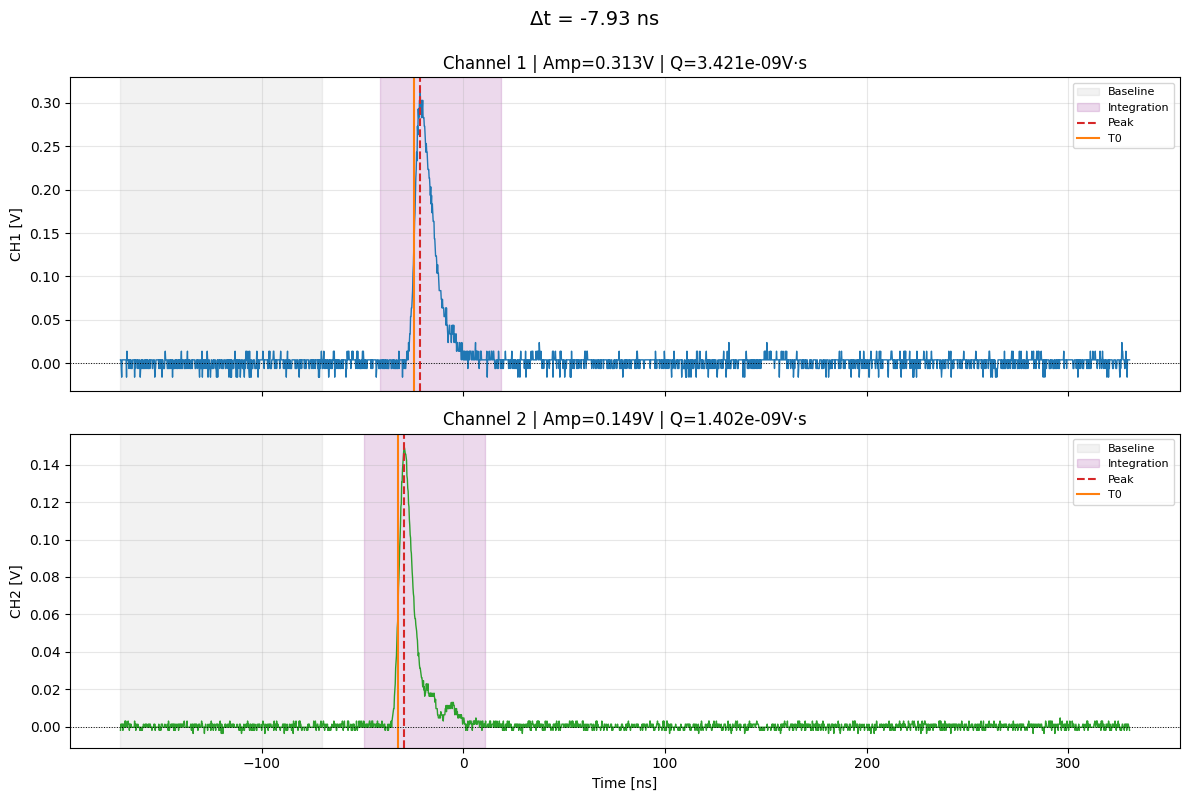

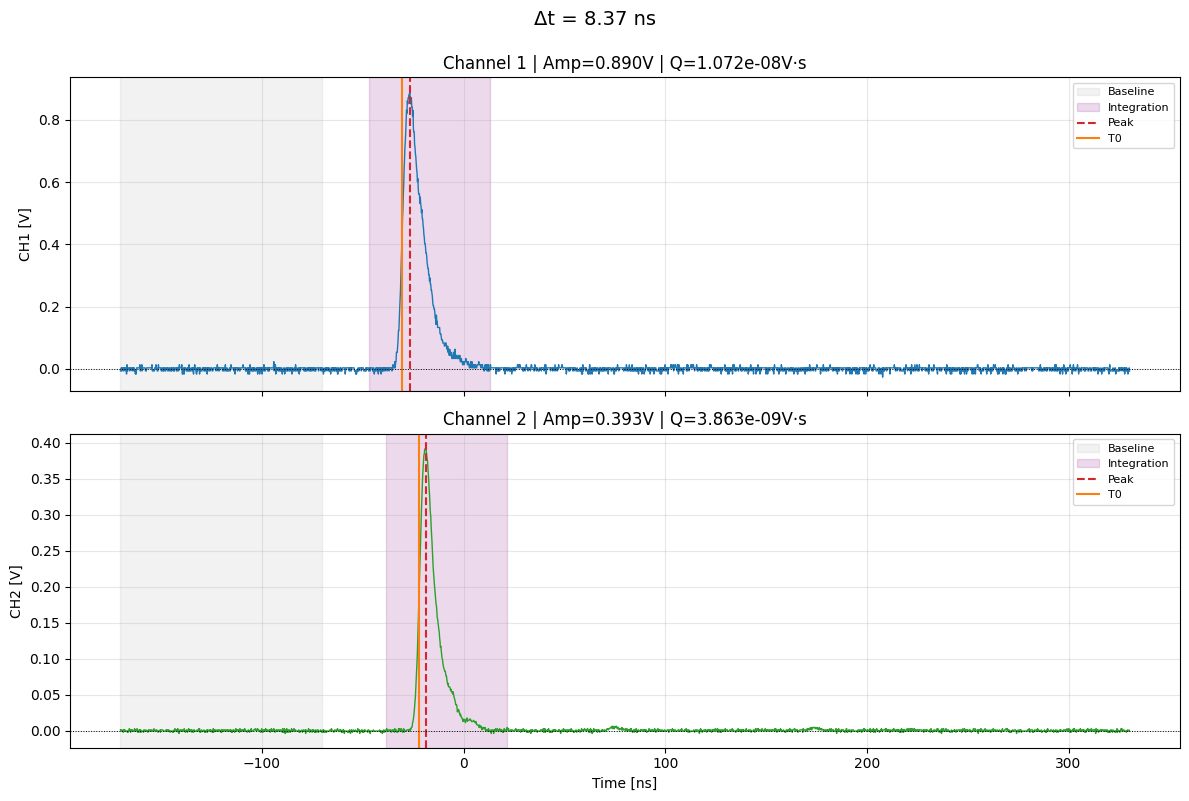

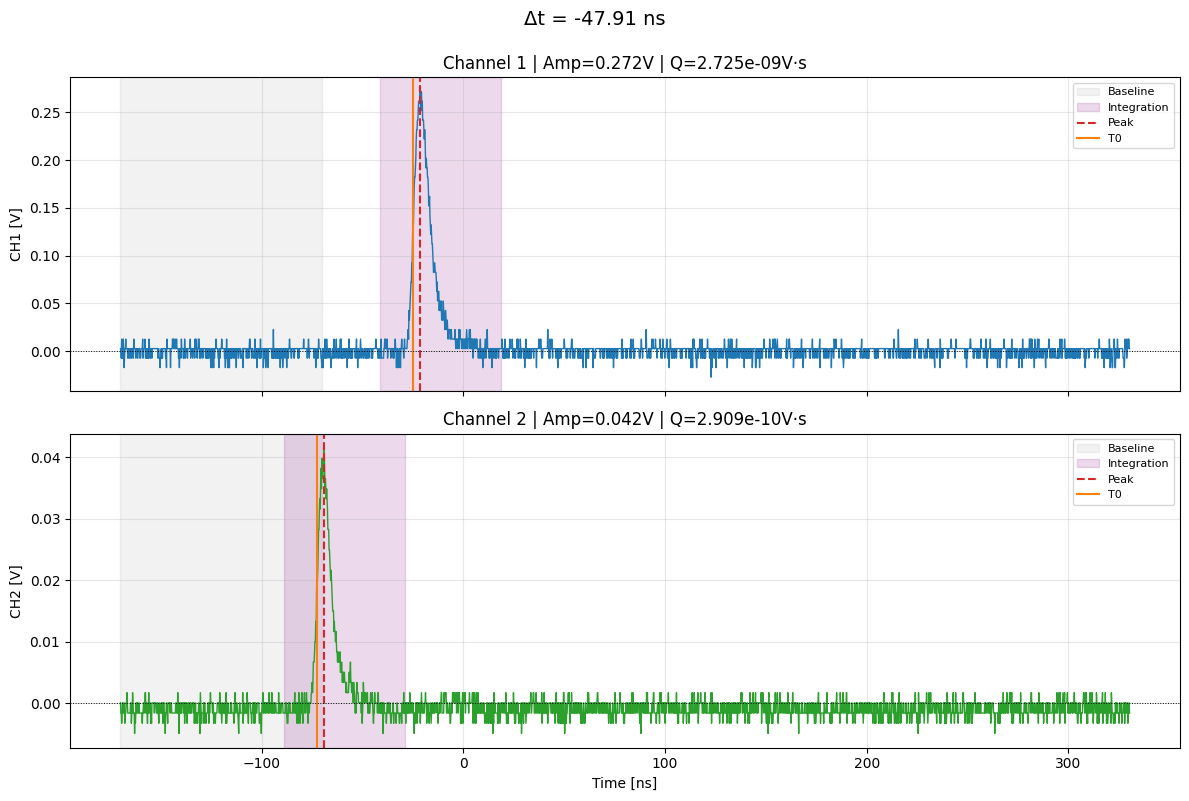

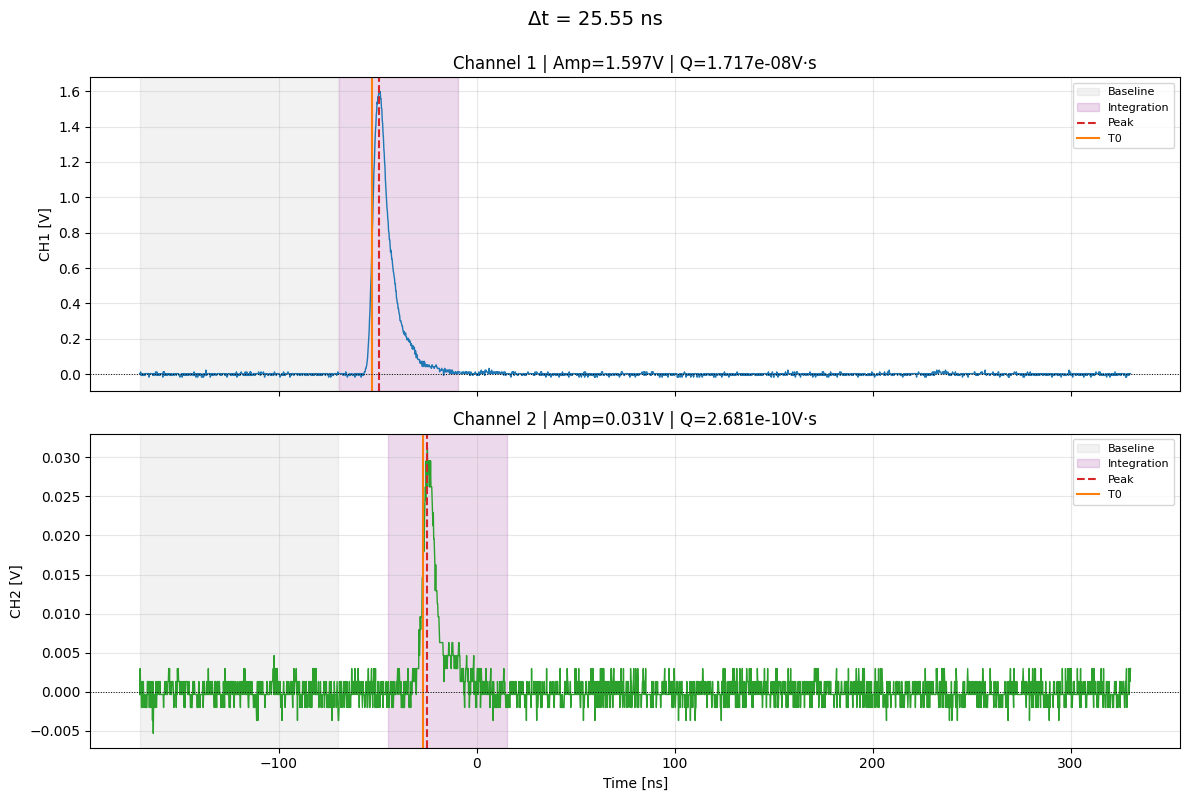

In [97]:
# Plot a few example pairs
n_examples = min(5, len(events_no_sat))
logger.info("Plotting %d example pairs...", n_examples)

for i in range(n_examples):
    event = events_no_sat[i]
    ch1_wf = load_waveform(event.ch1_path)
    ch2_wf = load_waveform(event.ch2_path)
    
    if ch1_wf and ch2_wf:
        save_path = config.results_dir / f"pair_example_{i:03d}.png"
        plot_pair_comparison(ch1_wf, ch2_wf, event, config, save_path=save_path)

2026-03-25 11:55:19,359 [INFO] Saved Δt histogram to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/delta_t_histogram.png



=== Summary Statistics (non-saturated events) ===

Total pairs analyzed: 11098
Non-saturated events: 9131
Saturation rate: 17.7%

Delta-t statistics (n=9131):
  Mean: 0.33 ns
  Std:  37.34 ns
  Min:  -126.30 ns
  Max:  115.10 ns


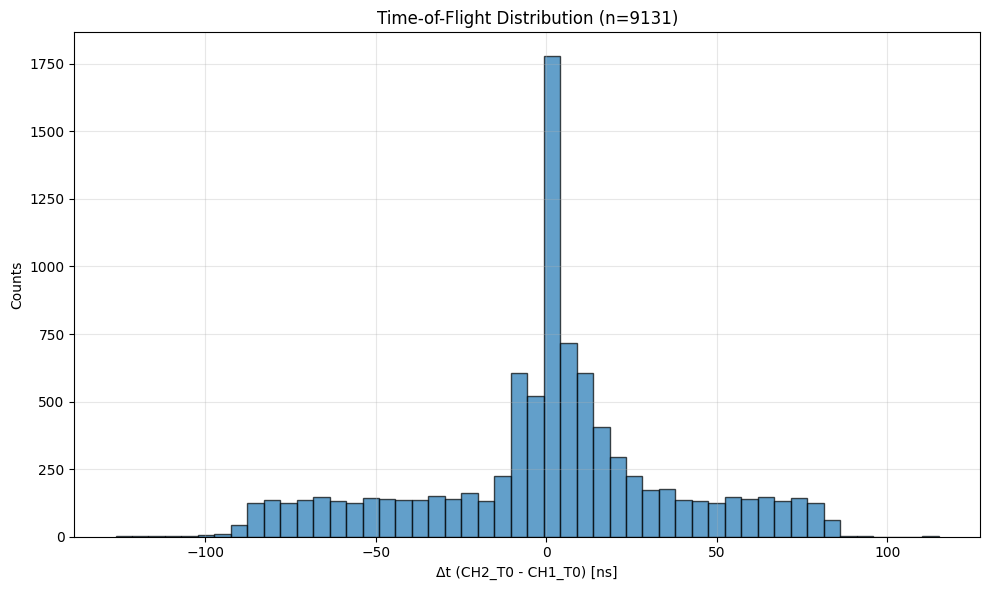

2026-03-25 11:55:19,476 [INFO] Saved charge distributions to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/charge_distributions.png


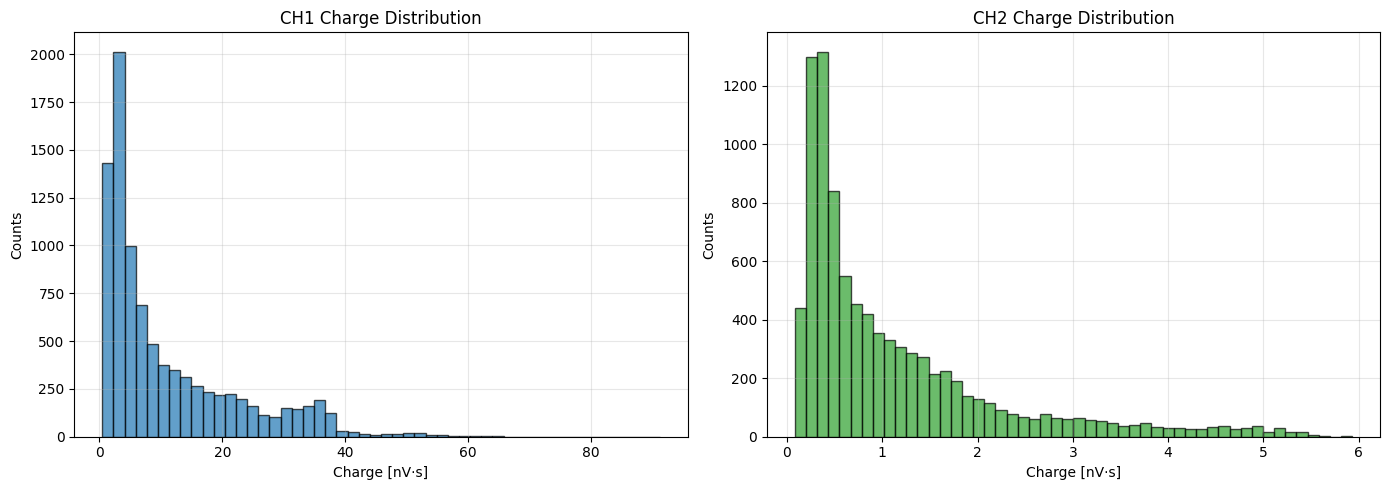

In [98]:
# Summary statistics
print("\n=== Summary Statistics (non-saturated events) ===")
print(f"\nTotal pairs analyzed: {len(events)}")
print(f"Non-saturated events: {len(events_no_sat)}")
print(f"Saturation rate: {100 * n_saturated / len(events):.1f}%\n")

if len(events_no_sat) > 0:
    delta_t_arr = np.array([e.delta_t_ns for e in events_no_sat if np.isfinite(e.delta_t_ns)])
    
    print(f"Delta-t statistics (n={len(delta_t_arr)}):")
    print(f"  Mean: {np.mean(delta_t_arr):.2f} ns")
    print(f"  Std:  {np.std(delta_t_arr):.2f} ns")
    print(f"  Min:  {np.min(delta_t_arr):.2f} ns")
    print(f"  Max:  {np.max(delta_t_arr):.2f} ns")
    
    # Plot delta-t histogram
    plt.figure(figsize=(10, 6))
    plt.hist(delta_t_arr, bins=50, alpha=0.7, edgecolor="black")
    plt.xlabel("Δt (CH2_T0 - CH1_T0) [ns]")
    plt.ylabel("Counts")
    plt.title(f"Time-of-Flight Distribution (n={len(delta_t_arr)})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    hist_path = config.results_dir / "delta_t_histogram.png"
    plt.savefig(hist_path, dpi=150)
    logger.info("Saved Δt histogram to: %s", hist_path)
    
    if config.show_plots:
        plt.show()
    else:
        plt.close()
    
    # CH1 and CH2 charge distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ch1_charge = np.array([e.ch1_charge_v_s for e in events_no_sat])
    ch2_charge = np.array([e.ch2_charge_v_s for e in events_no_sat])
    
    axes[0].hist(ch1_charge * 1e9, bins=50, alpha=0.7, edgecolor="black", color="tab:blue")
    axes[0].set_xlabel("Charge [nV·s]")
    axes[0].set_ylabel("Counts")
    axes[0].set_title("CH1 Charge Distribution")
    axes[0].grid(alpha=0.3)
    
    axes[1].hist(ch2_charge * 1e9, bins=50, alpha=0.7, edgecolor="black", color="tab:green")
    axes[1].set_xlabel("Charge [nV·s]")
    axes[1].set_ylabel("Counts")
    axes[1].set_title("CH2 Charge Distribution")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    charge_hist_path = config.results_dir / "charge_distributions.png"
    plt.savefig(charge_hist_path, dpi=150)
    logger.info("Saved charge distributions to: %s", charge_hist_path)
    
    if config.show_plots:
        plt.show()
    else:
        plt.close()

## Analysis Complete

### Outputs:
- Stacked waveform plots for CH1 and CH2 (identify neutron vs gamma)
- `two_channel_all_events.csv`: All events with timing and charge
- `two_channel_no_saturation.csv`: Events with neutron channel not saturated
- `delta_t_histogram.png`: Time-of-flight distribution
- `charge_distributions.png`: Charge histograms for both channels
- Example pair plots showing both channels with T0 markers

### Next Steps:
1. Review stacked plots to confirm neutron/gamma channel assignment
2. Adjust `NEUTRON_CHANNEL` variable if needed and re-run analysis
3. Tune thresholds (baseline window, charge window, T0 threshold fraction)
4. Analyze correlation between Δt and amplitudes/charges
5. Apply additional cuts (baseline quality, amplitude ranges, etc.)

## Generate PDF Report

Create a comprehensive PDF report with all analysis results and visualizations.

In [99]:
# Generate comprehensive PDF report
from lib import create_analysis_report

# Define output path
pdf_report_path = config.results_dir / "neutron_gamma_analysis_report.pdf"

# Use the all events CSV file
csv_results = config.results_dir / "two_channel_all_events.csv"

if csv_results.exists():
    print(f"Creating PDF report from {csv_results}...")
    create_analysis_report(
        csv_path=csv_results,
        output_pdf=pdf_report_path,
        waveform_dir=config.waveform_dir,
        title="AmBe Thermal Neutron Coincidence Analysis"
    )
    print(f"\n✓ PDF report saved to: {pdf_report_path}")
    print(f"  File size: {pdf_report_path.stat().st_size / 1024:.1f} KB")
else:
    print(f"Error: CSV file not found at {csv_results}")
    print("Please run the analysis cells first (cells 8-10) to generate the CSV.")


Creating PDF report from /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/two_channel_all_events.csv...


2026-03-25 11:55:20,552 [INFO] PDF report saved to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/neutron_gamma_analysis_report.pdf



✓ PDF report saved to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/neutron_gamma_analysis_report.pdf
  File size: 1137.3 KB


## Neutron Capture Analysis with Time-of-Flight Cut

For thermal neutrons captured in borated plastic scintillator after traveling through HDPE moderator and air gap, we expect Δt > 20 ns. This cut selects true neutron capture events from the coincidence data.

### Delta-t Definition and Sign Convention

**Definition:** `delta_t_ns = CH2_T0 - CH1_T0`

Where:
- **CH1 = Gamma detector** (prompt signal)
- **CH2 = Neutron detector** (borated scintillator)

**Physics:**
1. AmBe source emits gamma ray + neutron simultaneously
2. **Gamma** travels at speed of light → hits CH1 almost instantly → **CH1_T0 is early** (small time)
3. **Neutron** moderates through HDPE (10 cm) + air (10 cm) → takes ~40-50 ns → hits CH2 later → **CH2_T0 is late** (large time)
4. Therefore: **delta_t = CH2_T0 - CH1_T0 > 0** for true neutron capture

**Cut:** `delta_t > 20 ns` correctly selects events where neutron arrives AFTER gamma (i.e., physical neutron capture events)

In [100]:
# Verify the delta_t sign convention
print("=== Delta-t Sign Convention Verification ===\n")
print(f"Definition: delta_t = CH2_T0 - CH1_T0")
print(f"  CH1 = Gamma detector (prompt)")
print(f"  CH2 = Neutron detector (delayed)\n")

# Look at the full distribution
print(f"Full distribution (all non-saturated events, n={len(events_no_sat)}):")
print(f"  Mean: {np.mean(delta_t_arr):.2f} ns")
print(f"  Median: {np.median(delta_t_arr):.2f} ns")
print(f"  Range: [{np.min(delta_t_arr):.2f}, {np.max(delta_t_arr):.2f}] ns\n")

# Count events in different regions
n_positive = np.sum(delta_t_arr > 0)
n_negative = np.sum(delta_t_arr < 0)
n_large_positive = np.sum(delta_t_arr > 20)
n_large_negative = np.sum(delta_t_arr < -20)

print(f"Event distribution by delta_t:")
print(f"  delta_t > 0:    {n_positive} events ({100*n_positive/len(delta_t_arr):.1f}%) - CH2 after CH1")
print(f"  delta_t < 0:    {n_negative} events ({100*n_negative/len(delta_t_arr):.1f}%) - CH2 before CH1")
print(f"  delta_t > 20:   {n_large_positive} events ({100*n_large_positive/len(delta_t_arr):.1f}%) - NEUTRON CAPTURE")
print(f"  delta_t < -20:  {n_large_negative} events ({100*n_large_negative/len(delta_t_arr):.1f}%)\n")

print(f"✓ Using delta_t > 20 ns is CORRECT for neutron capture events")
print(f"  (selects events where neutron arrives AFTER gamma)")

=== Delta-t Sign Convention Verification ===

Definition: delta_t = CH2_T0 - CH1_T0
  CH1 = Gamma detector (prompt)
  CH2 = Neutron detector (delayed)

Full distribution (all non-saturated events, n=9131):
  Mean: 0.33 ns
  Median: 2.27 ns
  Range: [-126.30, 115.10] ns

Event distribution by delta_t:
  delta_t > 0:    5467 events (59.9%) - CH2 after CH1
  delta_t < 0:    3664 events (40.1%) - CH2 before CH1
  delta_t > 20:   2058 events (22.5%) - NEUTRON CAPTURE
  delta_t < -20:  1993 events (21.8%)

✓ Using delta_t > 20 ns is CORRECT for neutron capture events
  (selects events where neutron arrives AFTER gamma)


In [101]:
# Apply delta_t cut for neutron capture events
# Thermal neutrons travel through HDPE + air before capture, expect delta_t > 20 ns
delta_t_cut = 20.0  # ns

# Filter events with delta_t > 20 ns (neutron arrives after gamma)
neutron_capture_events = [e for e in events_no_sat if e.delta_t_ns > delta_t_cut]

logger.info("Applied Δt > %.1f ns cut", delta_t_cut)
logger.info("Events before cut: %d", len(events_no_sat))
logger.info("Neutron capture events: %d (%.1f%%)", 
           len(neutron_capture_events), 
           100 * len(neutron_capture_events) / len(events_no_sat) if events_no_sat else 0)

# Extract charge distributions for neutron capture events
if len(neutron_capture_events) > 0:
    neutron_ch1_charge = np.array([e.ch1_charge_v_s for e in neutron_capture_events])
    neutron_ch2_charge = np.array([e.ch2_charge_v_s for e in neutron_capture_events])
    neutron_delta_t = np.array([e.delta_t_ns for e in neutron_capture_events])
    
    print(f"\n=== Neutron Capture Statistics ===")
    print(f"Number of events: {len(neutron_capture_events)}")
    print(f"\nΔt statistics:")
    print(f"  Mean: {np.mean(neutron_delta_t):.2f} ns")
    print(f"  Std:  {np.std(neutron_delta_t):.2f} ns")
    print(f"  Median: {np.median(neutron_delta_t):.2f} ns")
    print(f"\nCH2 (Neutron) Charge:")
    print(f"  Mean: {np.mean(neutron_ch2_charge)*1e9:.2f} nV·s")
    print(f"  Median: {np.median(neutron_ch2_charge)*1e9:.2f} nV·s")
    print(f"\nCH1 (Gamma) Charge:")
    print(f"  Mean: {np.mean(neutron_ch1_charge)*1e9:.2f} nV·s")
    print(f"  Median: {np.median(neutron_ch1_charge)*1e9:.2f} nV·s")
else:
    logger.warning("No events passed the delta_t cut")

2026-03-25 11:55:20,563 [INFO] Applied Δt > 20.0 ns cut
2026-03-25 11:55:20,563 [INFO] Events before cut: 9131
2026-03-25 11:55:20,563 [INFO] Neutron capture events: 2058 (22.5%)



=== Neutron Capture Statistics ===
Number of events: 2058

Δt statistics:
  Mean: 48.53 ns
  Std:  19.25 ns
  Median: 47.27 ns

CH2 (Neutron) Charge:
  Mean: 0.86 nV·s
  Median: 0.56 nV·s

CH1 (Gamma) Charge:
  Mean: 9.43 nV·s
  Median: 5.11 nV·s


2026-03-25 11:55:20,685 [INFO] Saved neutron capture charge distributions to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/neutron_capture_charge_distributions.png


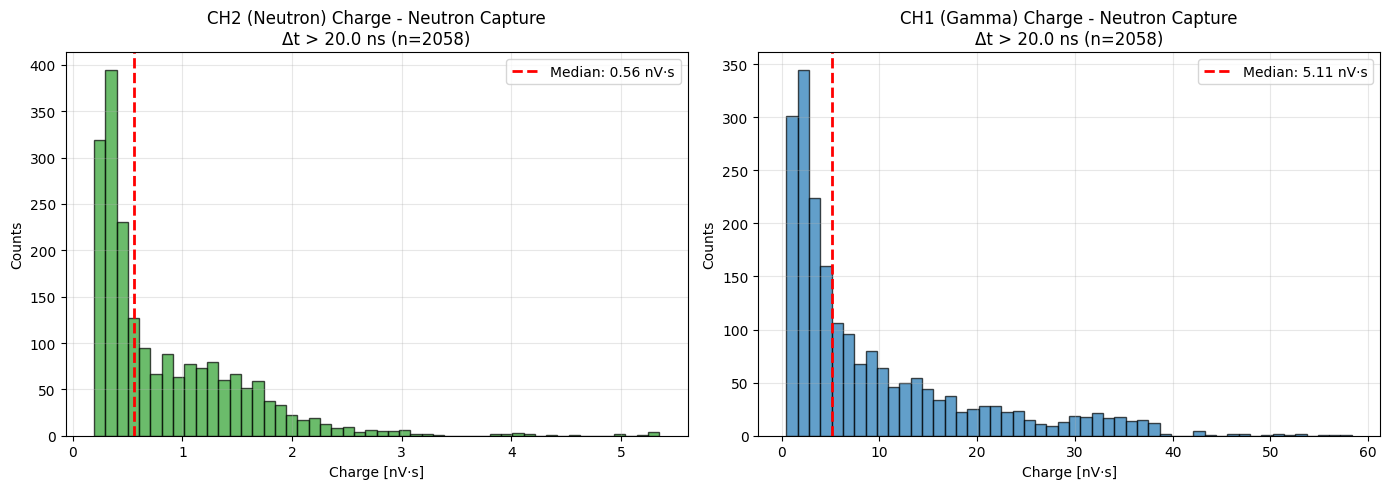

In [102]:
# Plot charge distributions for neutron capture events
if len(neutron_capture_events) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # CH2 (Neutron detector) charge distribution
    axes[0].hist(neutron_ch2_charge * 1e9, bins=50, alpha=0.7, edgecolor="black", color="tab:green")
    axes[0].set_xlabel("Charge [nV·s]")
    axes[0].set_ylabel("Counts")
    axes[0].set_title(f"CH2 (Neutron) Charge - Neutron Capture\nΔt > {delta_t_cut} ns (n={len(neutron_capture_events)})")
    axes[0].grid(alpha=0.3)
    axes[0].axvline(np.median(neutron_ch2_charge * 1e9), color='red', linestyle='--', 
                    linewidth=2, label=f'Median: {np.median(neutron_ch2_charge)*1e9:.2f} nV·s')
    axes[0].legend()
    
    # CH1 (Gamma detector) charge distribution
    axes[1].hist(neutron_ch1_charge * 1e9, bins=50, alpha=0.7, edgecolor="black", color="tab:blue")
    axes[1].set_xlabel("Charge [nV·s]")
    axes[1].set_ylabel("Counts")
    axes[1].set_title(f"CH1 (Gamma) Charge - Neutron Capture\nΔt > {delta_t_cut} ns (n={len(neutron_capture_events)})")
    axes[1].grid(alpha=0.3)
    axes[1].axvline(np.median(neutron_ch1_charge * 1e9), color='red', linestyle='--', 
                    linewidth=2, label=f'Median: {np.median(neutron_ch1_charge)*1e9:.2f} nV·s')
    axes[1].legend()
    
    plt.tight_layout()
    
    neutron_charge_path = config.results_dir / "neutron_capture_charge_distributions.png"
    plt.savefig(neutron_charge_path, dpi=150)
    logger.info("Saved neutron capture charge distributions to: %s", neutron_charge_path)
    
    if config.show_plots:
        plt.show()
    else:
        plt.close()

2026-03-25 11:55:20,812 [INFO] Saved neutron capture ToF distribution to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/neutron_capture_tof_distribution.png


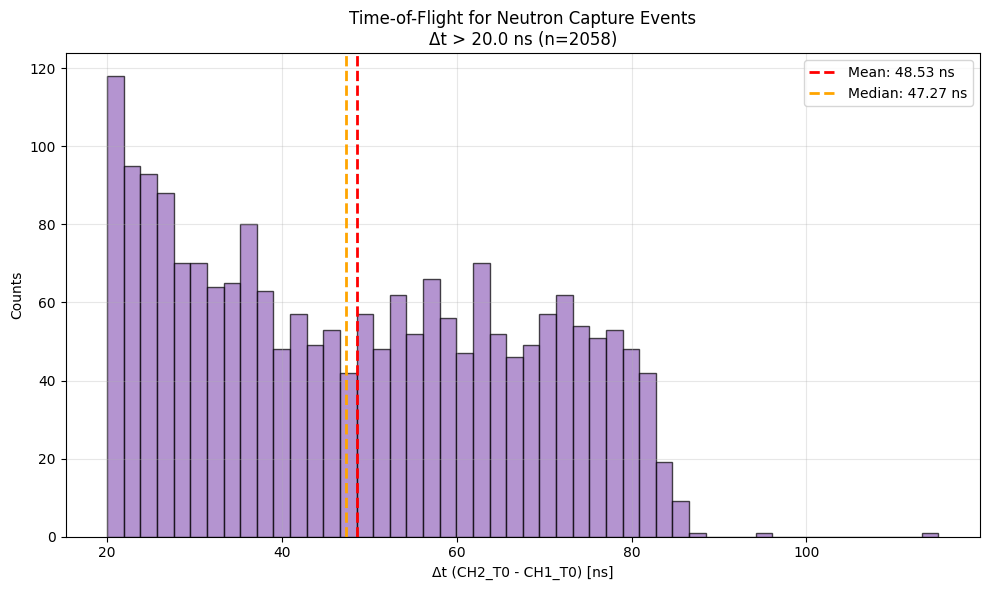

In [103]:
# Plot delta_t distribution for neutron capture events
if len(neutron_capture_events) > 0:
    plt.figure(figsize=(10, 6))
    plt.hist(neutron_delta_t, bins=50, alpha=0.7, edgecolor="black", color="tab:purple")
    plt.xlabel("Δt (CH2_T0 - CH1_T0) [ns]")
    plt.ylabel("Counts")
    plt.title(f"Time-of-Flight for Neutron Capture Events\nΔt > {delta_t_cut} ns (n={len(neutron_capture_events)})")
    plt.axvline(np.mean(neutron_delta_t), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(neutron_delta_t):.2f} ns')
    plt.axvline(np.median(neutron_delta_t), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(neutron_delta_t):.2f} ns')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    neutron_tof_path = config.results_dir / "neutron_capture_tof_distribution.png"
    plt.savefig(neutron_tof_path, dpi=150)
    logger.info("Saved neutron capture ToF distribution to: %s", neutron_tof_path)
    
    if config.show_plots:
        plt.show()
    else:
        plt.close()

In [104]:
# Save neutron capture events to CSV
if len(neutron_capture_events) > 0:
    df_neutron_capture = pd.DataFrame([e.to_dict() for e in neutron_capture_events])
    csv_neutron = config.results_dir / "neutron_capture_events.csv"
    df_neutron_capture.to_csv(csv_neutron, index=False)
    logger.info("Saved neutron capture events to: %s", csv_neutron)
    print(f"\nSaved {len(neutron_capture_events)} neutron capture events to CSV")

2026-03-25 11:55:20,865 [INFO] Saved neutron capture events to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/neutron_capture_events.csv



Saved 2058 neutron capture events to CSV


## Thermal Neutron Charge Spectrum (Borated Scintillator)

2026-03-25 11:55:21,114 [INFO] Saved thermal neutron charge spectrum to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/thermal_neutron_charge_spectrum.png



=== Thermal Neutron Charge Statistics (CH2 - Borated Scintillator) ===
Number of events: 2058

Charge Distribution:
  Mean:   0.86 nV·s
  Median: 0.56 nV·s
  Std:    0.70 nV·s
  Min:    0.19 nV·s
  Max:    5.35 nV·s

Percentiles:
  25th:   0.34 nV·s
  50th:   0.56 nV·s
  75th:   1.24 nV·s
  90th:   1.74 nV·s
  95th:   2.12 nV·s


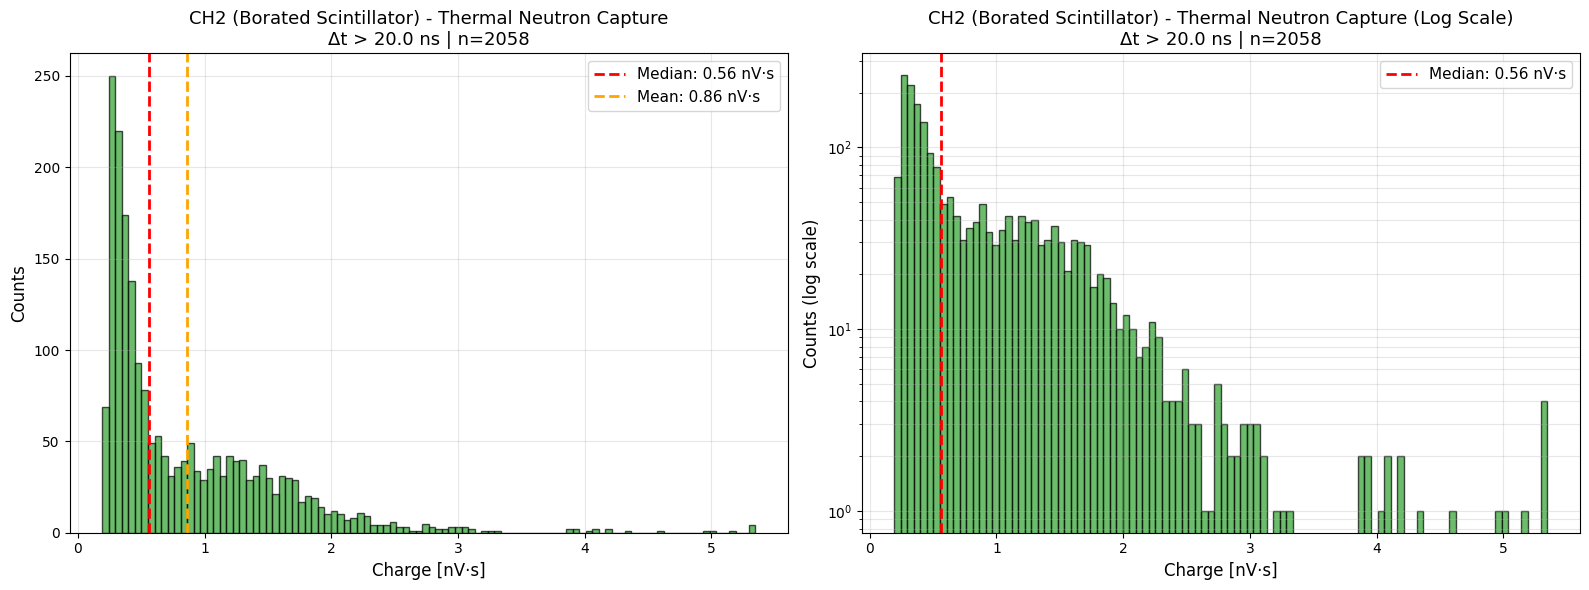

In [105]:
# Detailed charge spectrum for thermal neutron capture in borated scintillator
if len(neutron_capture_events) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Linear scale
    axes[0].hist(neutron_ch2_charge * 1e9, bins=100, alpha=0.7, edgecolor="black", color="tab:green")
    axes[0].set_xlabel("Charge [nV·s]", fontsize=12)
    axes[0].set_ylabel("Counts", fontsize=12)
    axes[0].set_title(f"CH2 (Borated Scintillator) - Thermal Neutron Capture\nΔt > {delta_t_cut} ns | n={len(neutron_capture_events)}", fontsize=13)
    axes[0].grid(alpha=0.3)
    
    # Add statistics
    mean_charge = np.mean(neutron_ch2_charge * 1e9)
    median_charge = np.median(neutron_ch2_charge * 1e9)
    std_charge = np.std(neutron_ch2_charge * 1e9)
    
    axes[0].axvline(median_charge, color='red', linestyle='--', linewidth=2, label=f'Median: {median_charge:.2f} nV·s')
    axes[0].axvline(mean_charge, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_charge:.2f} nV·s')
    axes[0].legend(fontsize=11)
    
    # Right plot: Log scale to see tail
    counts, bins, patches = axes[1].hist(neutron_ch2_charge * 1e9, bins=100, alpha=0.7, edgecolor="black", color="tab:green")
    axes[1].set_xlabel("Charge [nV·s]", fontsize=12)
    axes[1].set_ylabel("Counts (log scale)", fontsize=12)
    axes[1].set_title(f"CH2 (Borated Scintillator) - Thermal Neutron Capture (Log Scale)\nΔt > {delta_t_cut} ns | n={len(neutron_capture_events)}", fontsize=13)
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.3, which='both')
    axes[1].axvline(median_charge, color='red', linestyle='--', linewidth=2, label=f'Median: {median_charge:.2f} nV·s')
    axes[1].legend(fontsize=11)
    
    plt.tight_layout()
    
    thermal_neutron_charge_path = config.results_dir / "thermal_neutron_charge_spectrum.png"
    plt.savefig(thermal_neutron_charge_path, dpi=150)
    logger.info("Saved thermal neutron charge spectrum to: %s", thermal_neutron_charge_path)
    
    # Print detailed statistics
    print(f"\n=== Thermal Neutron Charge Statistics (CH2 - Borated Scintillator) ===")
    print(f"Number of events: {len(neutron_capture_events)}")
    print(f"\nCharge Distribution:")
    print(f"  Mean:   {mean_charge:.2f} nV·s")
    print(f"  Median: {median_charge:.2f} nV·s")
    print(f"  Std:    {std_charge:.2f} nV·s")
    print(f"  Min:    {np.min(neutron_ch2_charge * 1e9):.2f} nV·s")
    print(f"  Max:    {np.max(neutron_ch2_charge * 1e9):.2f} nV·s")
    print(f"\nPercentiles:")
    print(f"  25th:   {np.percentile(neutron_ch2_charge * 1e9, 25):.2f} nV·s")
    print(f"  50th:   {np.percentile(neutron_ch2_charge * 1e9, 50):.2f} nV·s")
    print(f"  75th:   {np.percentile(neutron_ch2_charge * 1e9, 75):.2f} nV·s")
    print(f"  90th:   {np.percentile(neutron_ch2_charge * 1e9, 90):.2f} nV·s")
    print(f"  95th:   {np.percentile(neutron_ch2_charge * 1e9, 95):.2f} nV·s")
    
    if config.show_plots:
        plt.show()
    else:
        plt.close()